In [1]:
import os
import json
import numpy as np
import glob
import time
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
from tqdm.auto import tqdm
import json_repair
import numpy as np

def load_jsonl_data(path):
    data = []
    with open(path) as reader:
        for row in reader:
            data.append(json.loads(row))
    return data

def write_jsonl_data(data, path):
    with open(path, 'w') as writer:
        for x in data:
            writer.write(json.dumps(x, ensure_ascii=False) + '\n')

class APIModel:
    def __init__(self, api_key, model):
        self.client = OpenAI(
            api_key=api_key, 
            base_url="https://api.ai-gaochao.cn/v1"
        )
        self.messages = []
        self.model = model
    
    def chat(self, messages):
        max_retries = 5
        for attempt in range(max_retries):
            try:
                response = self.client.chat.completions.create(
                    model=self.model,
                    messages=messages,
                    temperature=1.0
                )
                response_content = response.choices[0].message.content
                messages1 = messages.copy()
                messages1.append({"role": "assistant", "content": response_content})
                self.messages.append(messages1)
            except Exception as e:
                if attempt == max_retries - 1:  # Last attempt
                    response_content = ""
                else:
                    # Wait before retry
                    time.sleep(2 ** attempt)  # Exponential backoff
                    continue

        return response_content

def process_single_item(model, item, index):
    """Process a single item with the model"""
    messages = [{
        'role': 'user',
        'content': item['input']
    }]
    
    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = model.chat(messages)
            item['output'] = response
            return index, item, None
        except Exception as e:
            if attempt == max_retries - 1:  # Last attempt
                print(f"Error occurred for item {index} after {max_retries} attempts: {e}")
                item['output'] = ""
                return index, item, str(e)
            else:
                # Wait before retry
                time.sleep(2 ** attempt)  # Exponential backoff
    
    return index, item, None

def process_data_concurrent(model, api_key, data, max_workers=5):
    results = [None] * len(data)
    error_count = 0
    lock = threading.Lock()
    
    thread_local = threading.local()
    
    def get_model():
        if not hasattr(thread_local, 'model'):
            thread_local.model = APIModel(api_key=api_key, model=model)
        return thread_local.model
    
    def process_item_with_thread_local(item_data):
        index, item = item_data
        model = get_model()
        return process_single_item(model, item, index)
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        print("Fast batch submission...")
        
        indexed_data = [(i, item.copy()) for i, item in enumerate(data)]
        
        futures = [executor.submit(process_item_with_thread_local, item_data) 
                  for item_data in indexed_data]
        
        print(f"Processing {len(futures)} tasks...")

        with tqdm(total=len(futures), desc="Processing") as pbar:
            for future in as_completed(futures):
                index, result, error = future.result()
                results[index] = result
                if error:
                    with lock:
                        error_count += 1
                pbar.set_postfix({'errors': error_count})
                pbar.update(1)
    
    return results

def _parse_json_response(text: str, keys: list) -> dict:
    import re
    
    try:
        try:
            match = re.search(r"```json\s*([\s\S]*?)\s*```", text)

            json_str = match.group(1).strip()
            result = json_repair.loads(json_str)
        except:
            result = json_repair.loads(text)

        for key in keys:
            if key not in result:
                result[key] = None

        return result

    except Exception as e:
        response = {k: None for k in keys}
        return response

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from dataclasses import dataclass, field, fields, asdict

@dataclass
class UserProfile:
    user_id: str
    religious: str
    employment: str
    marital: str
    race: str
    income: str
    area: str
    age: str
    gender: str
    bigfive: dict
    personality: list
    preferences: list
    preferences_value: dict
    extra: dict = field(default_factory=dict)

    @classmethod
    def from_dict(cls, data: dict):
        data = {k.lower(): v for k, v in data.items()}

        field_names = {f.name for f in fields(cls) if f.name != "extra"}
        
        known = {name: data.get(name, None) for name in field_names}
        extra = {k: v for k, v in data.items() if k not in field_names}
        
        return cls(**known, extra=extra)

    def to_dict(self) -> dict:
        base = asdict(self)
        base.update(self.extra)
        base.pop("extra", None)
        return base

    def desc(self, keys_to_drop: list = []):
        """
        Convert structured profile to a descriptive string.
        """
        base_info_parts = []

        attrs = [
            ("gender", "{}"),
            ("age", "{}"),
            ("race", "{}"),
            ("marital", "{}"),
            ("religious", "user's religion is {}"),
            ("area", "usually resides in {}"),
        ]

        for attr_name, fmt in attrs:
            if attr_name in keys_to_drop:
                continue
            value = getattr(self, attr_name, None)
            if not value:
                continue
            if attr_name == "religious":
                if value == "No religion":
                    base_info_parts.append("no religious affiliation")
                else:
                    base_info_parts.append(fmt.format(value))
            else:
                base_info_parts.append(fmt.format(value))

        base_info = ", ".join(base_info_parts)

        politics_econ_parts = []
        if "income" not in keys_to_drop and self.income:
            politics_econ_parts.append(f"the income level is {self.income}")
        if "employment" not in keys_to_drop and self.employment:
            politics_econ_parts.append(f"{self.employment}")
        politics_econ_text = ", ".join(politics_econ_parts)

        personality_text = ""
        if "personality" not in keys_to_drop and self.personality:
            personality_text = "Personality traits include: " + "、".join(self.personality)

        preferences_text = ""
        if "preferences" not in keys_to_drop and self.preferences:
            preferences_text = "Preferences expressed in daily life and interactions include: " + " ".join(self.preferences)

        parts = [base_info, politics_econ_text, personality_text, preferences_text]
        return ". ".join([p for p in parts if p])

    def __str__(self) -> str:
        return self.desc()

In [8]:
def get_final_data():
    fd = {}
    
    event_path = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/data/event_sequences/total/events.jsonl'
    user_path = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/data/event_sequences/total/users.jsonl'

    final_data = load_jsonl_data(event_path)
    user_data = load_jsonl_data(user_path)
    user_data = {x['user_id']: x for x in user_data}

    for x in final_data:
        user_profile = UserProfile.from_dict(user_data[x['user_id']])
        x['profile_str'] = str(user_profile)

    fd['livesim'] = final_data
    
    name2path = {
        'profile_mob2traj': '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/exp_results/events_baseline/event_sequences_profile_mob2traj',
        'profile2traj': '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/exp_results/events_baseline/event_sequences_profile2traj'
    }
    for name in name2path:
        root = name2path[name]
        _dir = os.path.join(root, '*')
        data = []
        for file in glob.glob(_dir):
            if file.endswith('tmp'):
                continue
            d = load_jsonl_data(file)
            data.append(d)

        final_data = []
        for d in data:
            n = 0
            d = d[::-1]
            for es in d:
                if len(es['results']) >= 10:
                    es['results'] = es['results'][:10]
                    final_data.append(es)
                    n += 1
                if n >= 15:
                    break
        fd[name] = final_data
    
    return fd

final_data = get_final_data()

In [5]:
# events = final_data['profile2traj']
events = final_data['livesim']
print(events[50]['profile_str'])
for x in events[50]['events']:
    print(x['event'])

Female, Middle-aged (36-65 years old), White Alone, Married, no religious affiliation, usually resides in Cities. the income level is Middle Income, Working now. Personality traits include: prone to nervousness、prone to worry、Positive.、Energetic.、Not good at reflecting.、lacking curiosity、uncooperative、Not easygoing.. Preferences expressed in daily life and interactions include: Has very high requirements for the work environment, paying attention to details such as spatial layout, facilities, and atmosphere culture, and will actively choose or create a workplace that perfectly meets expectations. Highly driven to achieve personal accomplishments, setting clear goals and persistently working towards them, with a strong desire to gain recognition and achieve self-fulfillment through achievements.
During a quick stop at a downtown convenience store while finishing packing for a day‑long business trip, she scans the snack aisle and sees mainly chips and candy, leaving her uneasy about find

In [7]:
# Personal Alignment
PA_PROMPT = '''You are an expert in evaluating the plausibility of event sequences, tasked with assessing whether a generated sequence of events aligns with a given user profile.
You will receive:  
- A User Profile  
- An Event Sequence
### Output Format
A JSON object containing only the final score:
Reasoning process ...
```json
{{
    "score": 1/2/3/4/5
}}
```
You may first output your reasoning process, followed by the JSON result.  
### Input
[User Profile]
{user_profile}
[Event Sequences]
{event_sequences}'''

def eval_pa(data, name):
    inputs = []
    for x in data:
        profile_str = x['profile_str']
        if 'results' in x:
            events = x['results']
            es = ''
            for i, e in enumerate(events):
                es += (
                    f"[{str(i)}]\n"
                    f"Time: {e['time']}\n"
                    f"Location: {e['location']}\n"
                    f"Weather: {e['weather']}\n"
                    f"Event: {e['life_event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            _input = PA_PROMPT.format(
                user_profile = profile_str,
                event_sequences = es
            )
            inputs.append({
                'input': _input
            })
        else:
            events = x['events']
            es = ''
            for i, e in enumerate(events):
                es += (
                    f"[{str(i)}]\n"
                    f"Time: {e['time']}\n"
                    f"Location: {e['location']}\n"
                    f"Weather: {e['weather']['description']}\n"
                    f"Event: {e['event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            _input = PA_PROMPT.format(
                user_profile = profile_str,
                event_sequences = es
            )
            inputs.append({
                'input': _input
            })

    write_jsonl_data(inputs, f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/{name}_pa_input.jsonl')

for name in final_data:
    eval_pa(final_data[name], name)

for name in final_data:
    results = load_jsonl_data(f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/{name}_pa_output.jsonl')
    scores = []
    for x in results:
        # print(x['output'])
        score = 0
        for xx in x['output']:
            s = _parse_json_response(xx, ['score'])['score']
            if not isinstance(s, int):
                s = 0
            score += s
            # print(_parse_json_response(xx, ['score'])['score'], end=',')
        # print()
        scores.append(score / len(x['output']))
    print(name, np.mean(scores) * 20)

livesim 96.96666666666667
profile_mob2traj 91.93333333333331
profile2traj 95.04999999999998


In [14]:
COH_PROMPT = '''You are an expert in evaluating the plausibility of event sequences, tasked with assessing whether the chronological and logical flow between events is coherent and reasonable.
You will receive:
An Event Sequence
### Output Format
A JSON object containing only the final score:  
Reasoning process ...
```json
{{
    "score": 1/2/3/4/5
}}
```
You may first output your reasoning process, followed by the JSON result.
### Input
[Event Sequences]
{event_sequences}'''

def eval_pa(data, name):
    inputs = []
    for x in data:
        if 'results' in x:
            events = x['results']
            es = ''
            for i, e in enumerate(events):
                es += (
                    f"[{str(i)}]\n"
                    f"Time: {e['time']}\n"
                    f"Location: {e['location']}\n"
                    f"Weather: {e['weather']}\n"
                    f"Event: {e['life_event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            _input = COH_PROMPT.format(
                event_sequences = es
            )
            inputs.append({
                'input': _input
            })
        else:
            events = x['events']
            es = ''
            for i, e in enumerate(events):
                es += (
                    f"[{str(i)}]\n"
                    f"Time: {e['time']}\n"
                    f"Location: {e['location']}\n"
                    f"Weather: {e['weather']['description']}\n"
                    f"Event: {e['event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            _input = COH_PROMPT.format(
                event_sequences = es
            )
            inputs.append({
                'input': _input
            })

    write_jsonl_data(inputs, f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/{name}_coh_input.jsonl')

for name in final_data:
    eval_pa(final_data[name], name)

for name in final_data:
    results = load_jsonl_data(f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/{name}_coh_output.jsonl')
    scores = []
    for x in results:
        # print(x['output'])
        # break
        score = 0
        if len(x['output']) > 0:
            for xx in x['output']:
                s = _parse_json_response(xx, ['score'])['score']
                if not isinstance(s, int):
                    s = 0
                score += s
                # print(_parse_json_response(xx, ['score'])['score'], end=',')
            # print()
            scores.append(score / len(x['output']))
    print(name, np.mean(scores) * 20)

livesim 96.89999999999999
profile_mob2traj 91.13333333333333
profile2traj 97.68333333333332


In [7]:
NAT_PROMPT = '''Your task is to assess the extent to which a given event sequence demonstrates naturalness and aligns with realistic human behavior.
You will receive:
- An Event Sequence
### Output Format
A JSON object containing only the final score:  
Reasoning process ...
```json
{{
    "score": 1/2/3/4/5
}}
```
You may first output your reasoning process, followed by the JSON result.
### Input
[Event Sequences]
{event_sequences}'''

def eval_pa(data, name):
    inputs = []
    for x in data:
        if 'results' in x:
            events = x['results']
            es = ''
            for i, e in enumerate(events):
                es += (
                    f"[{str(i)}]\n"
                    f"Time: {e['time']}\n"
                    f"Location: {e['location']}\n"
                    f"Weather: {e['weather']}\n"
                    f"Event: {e['life_event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            _input = NAT_PROMPT.format(
                event_sequences = es
            )
            inputs.append({
                'input': _input
            })
        else:
            events = x['events']
            es = ''
            for i, e in enumerate(events):
                es += (
                    f"[{str(i)}]\n"
                    f"Time: {e['time']}\n"
                    f"Location: {e['location']}\n"
                    f"Weather: {e['weather']['description']}\n"
                    f"Event: {e['event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            _input = NAT_PROMPT.format(
                event_sequences = es
            )
            inputs.append({
                'input': _input
            })

    write_jsonl_data(inputs, f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/{name}_nat_input.jsonl')

for name in final_data:
    eval_pa(final_data[name], name)

for name in final_data:
    results = load_jsonl_data(f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/{name}_nat_output.jsonl')
    scores = []
    for x in results:
        # print(x['output'])
        score = 0
        if len(x['output']) > 0:
            for xx in x['output']:
                # print(xx)
                # print('---')
                s = _parse_json_response(xx, ['score'])['score']
                if not isinstance(s, int):
                    s = 0
                score += s
                # print(_parse_json_response(xx, ['score'])['score'], end=',')
            # print()
            scores.append(score / len(x['output']))
    print(name, np.mean(scores) * 20)

livesim 95.90909090909088
profile_mob2traj 91.72413793103448
profile2traj 97.49999999999999


In [43]:
COMPARE_PROMPT = '''You are an expert in evaluating the naturalness and realism of event sequences. 
You task is to compare which event sequence is more real?
### Output Format
Output your answer in json format:
```json
{{
    "ans": 1/2
}}
```
You could give your reason before the final answer.
### Input
[Event Sequences 1]
{event_sequences1}
[Event Sequences 2]
{event_sequences2}
'''

events = {}
for name in final_data:
    events[name] = []
    for x in final_data[name]:
        if 'results' in x:
            _events = x['results']
            es = ''
            for i, e in enumerate(_events):
                es += (
                    f"[{str(i)}]\n"
                    # f"Time: {e['time']}\n"
                    # f"Location: {e['location']}\n"
                    # f"Weather: {e['weather']}\n"
                    f"Event: {e['life_event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            events[name].append(es)
        else:
            _events = x['events']
            es = ''
            for i, e in enumerate(_events):
                es += (
                    f"[{str(i)}]\n"
                    # f"Time: {e['time']}\n"
                    # f"Location: {e['location']}\n"
                    # f"Weather: {e['weather']['description']}\n"
                    f"Event: {e['event']}\n"
                    f"Intent: {e['intent']}\n"
                )
            
            events[name].append(es)

inputs = []
for e1, e2 in zip(events['livesim'], events['profile_mob2traj']):
    _input = COMPARE_PROMPT.format(
        event_sequences1 = e1,
        event_sequences2 = e2
    )
    inputs.append({
        'input': _input
    })
    _input = COMPARE_PROMPT.format(
        event_sequences1 = e2,
        event_sequences2 = e1
    )
    inputs.append({
        'input': _input
    })

write_jsonl_data(inputs, f'/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/compare1_input.jsonl')

results = load_jsonl_data('/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance/compare_output.jsonl')
win_rates = []
for x in results:
    rs = []
    for xx in x['output']:
        r = _parse_json_response(xx, ['ans'])['ans']
        rs.append(int(int(r) == 1))
    rs = int(sum(rs) >= 3)
    win_rates.append(rs)

print(np.mean(win_rates))

0.5625


In [ ]:
root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/event_performance'

path = os.path.join(root, 'livesim_coh.jsonl')
results = load_jsonl_data(path)

scores = []
for x in results:
    output = _parse_json_response(x['output'], [])
    scores.append(output['score'])

print('COH', np.mean(scores))

In [22]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/MODELS/Qwen3-Embedding-0.6B",
    model_kwargs={"device_map": "auto"},
    tokenizer_kwargs={"padding_side": "left"},
)

100%|██████████| 120/120 [00:16<00:00,  7.39it/s]


livesim
R-2 0.5753139
R-4 0.57329786
R-6 0.5694671


100%|██████████| 120/120 [00:09<00:00, 12.46it/s]


profile_mob2traj
R-2 0.58502513
R-4 0.5870909
R-6 0.5879232


100%|██████████| 120/120 [00:09<00:00, 12.43it/s]


profile2traj
R-2 0.53032625
R-4 0.53460187
R-6 0.5373544


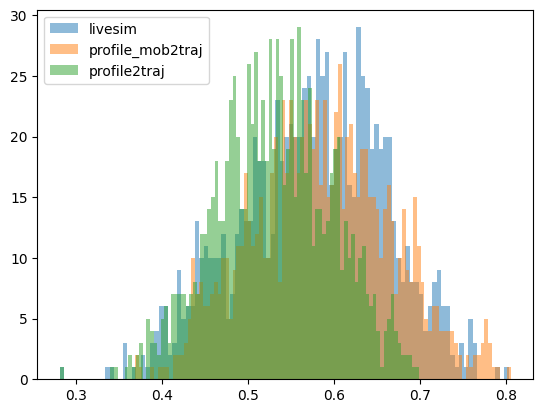

In [23]:
def calculate_R(queries, documents, n=4):
    query_embeddings = model.encode(queries)
    document_embeddings = model.encode(documents)

    similarity = model.similarity(query_embeddings, document_embeddings)
    return similarity.cpu().numpy()

from matplotlib import pyplot as plt

for name in final_data:
    r_2_scores = []
    r_4_scores = []
    r_6_scores = []
    for x in tqdm(final_data[name]):
        if 'events' in x:
            events = [f"[time]{xx['time']} [Location]{xx['location']} [Event]{xx['event']} [Intent]{xx['intent']}" for xx in x['events']]
        else:
            events = [f"[time]{xx['time']} [Location]{xx['location']} [Event]{xx['life_event']} [Intent]{xx['intent']}" for xx in x['results']]
        sim = calculate_R(events, events)
        for i in range(2, sim.shape[0]):
            r_2_score = sim[i, i-2:i].mean()
            r_2_scores.append(r_2_score)
        for i in range(4, sim.shape[0]):
            r_4_score = sim[i, i-4:i].mean()
            r_4_scores.append(r_4_score)
        for i in range(6, sim.shape[0]):
            r_6_score = sim[i, i-6:i].mean()
            r_6_scores.append(r_6_score)

    print(name)
    print('R-2', np.mean(r_2_scores))
    plt.hist(r_2_scores, bins=100, alpha=0.5, label=name)
    print('R-4', np.mean(r_4_scores))
    print('R-6', np.mean(r_6_scores))

plt.legend()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/MODELS/Qwen3-Embedding-0.6B",
    model_kwargs={"device_map": "auto"},
    tokenizer_kwargs={"padding_side": "left"},
)

In [ ]:
import numpy as np
import hdbscan
from collections import Counter

def compute_semantic_redundancy(embeddings, min_cluster_size=5, min_samples=None, top_k_ratio=0.1):
    """
    使用 HDBSCAN 对事件向量进行语义聚类，并计算重复性指标。

    参数：
        embeddings: np.array, shape = (N, D)
        min_cluster_size: HDBSCAN 的最小簇大小
        min_samples: HDBSCAN min_samples（None 表示与 min_cluster_size 相同）
        top_k_ratio: 用于计算“前 K% 最大簇占比”的比例

    返回：
        一个字典包含：
            - cluster_labels
            - num_clusters
            - cluster_size_variance
            - dominance_top_k_ratio
            - semantic_redundancy_index
            - cluster_size_distribution
    """

    # Step 1: 聚类
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean'
    )
    labels = clusterer.fit_predict(embeddings)

    # -1 是噪声点，不计入簇
    valid_labels = labels[labels != -1]
    N = len(embeddings)

    if len(valid_labels) == 0:
        # 全部噪声，则几乎无冗余
        return {
            "cluster_labels": labels.tolist(),
            "num_clusters": 0,
            "cluster_size_variance": 0.0,
            "dominance_top_k_ratio": 0.0,
            "semantic_redundancy_index": 0.0,
            "cluster_size_distribution": {}
        }

    # Step 2: 统计簇大小（不含 noise）
    cluster_count = Counter(valid_labels)
    sizes = np.array(list(cluster_count.values()))
    num_clusters = len(sizes)

    # Step 3: 聚类大小方差（越大表示有头部簇占主导）
    cluster_size_variance = np.var(sizes)

    # Step 4: 计算 Top-K 最大簇集中度
    K = max(1, int(num_clusters * top_k_ratio))
    top_k_sizes = np.sort(sizes)[-K:]
    dominance_top_k_ratio = top_k_sizes.sum() / N

    # Step 5: Semantic Redundancy Index（簇数量越少冗余越大）
    semantic_redundancy_index = 1.0 - num_clusters / N

    return {
        "cluster_labels": labels.tolist(),
        "num_clusters": num_clusters,
        "cluster_size_variance": cluster_size_variance,
        "dominance_top_k_ratio": dominance_top_k_ratio,
        "semantic_redundancy_index": semantic_redundancy_index,
        "cluster_size_distribution": dict(cluster_count)
    }

In [ ]:
for name in final_data:
    events = []
    for x in final_data[name]:
        if 'events' in x:
            events.extend([xx['event'] for xx in x['events']])
        else:
            events.extend([xx['life_event'] for xx in x['results']])

    embeddings = model.encode(events)
    result = compute_semantic_redundancy(embeddings=embeddings, min_cluster_size=20)
    print(name)
    print(result['cluster_size_variance'])

In [5]:
import random
random.seed(42)

gold_events_path1 = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/data/foursquare/formatted_foursquare_NYC.jsonl'
gold_events_path2 = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/data/foursquare/formatted_foursquare_TKY.jsonl'
gold_events1 = load_jsonl_data(gold_events_path1)
gold_events2 = load_jsonl_data(gold_events_path2)
gold_events = gold_events1 + gold_events2

print(gold_events[0])

sub_gold_events = random.sample(gold_events, 300)
gold_events = []
for es in sub_gold_events:
    s = random.randint(0, len(es['events'])-20)
    es['events'] = es['events'][s: s+10]
    # es['events'].sort(key=lambda x: x['timestamp'])
    gold_events.append(es)

{'name': '470_NYC', 'events': [{'time': 'Tue Apr 03 18:00:09 +0000 2012', 'location_detail': {'latitude': 40.71981038, 'longitude': -74.00258103}, 'location': 'Arts & Crafts Store', 'event': 'culture & arts', 'timestamp': '2012-04-03 18:00:09', 'weather': {'datetime': '2012-04-03', 'datetimeEpoch': 1333425600, 'tempmax': 13.7, 'tempmin': -0.9, 'temp': 6.6, 'feelslikemax': 13.7, 'feelslikemin': -5.4, 'feelslike': 4.4, 'dew': -9.1, 'humidity': 34.2, 'precip': 0.0, 'precipprob': 0.0, 'precipcover': 0.0, 'preciptype': None, 'snow': 0.0, 'snowdepth': 0.0, 'windgust': 38.9, 'windspeed': 28.6, 'winddir': 297.6, 'pressure': 1011.0, 'cloudcover': 30.3, 'visibility': 16.0, 'solarradiation': None, 'solarenergy': None, 'uvindex': None, 'sunrise': '06:32:58', 'sunriseEpoch': 1333449178, 'sunset': '19:23:59', 'sunsetEpoch': 1333495439, 'moonphase': 0.4, 'conditions': 'Partially cloudy', 'description': 'Partly cloudy throughout the day.', 'icon': 'partly-cloudy-day', 'stations': ['72518014735', 'KPSF

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import matplotlib.ticker as mticker

def plot_smooth_pdf(p, bin_edges, label, linewidth=2):
    bin_edges = np.asarray(bin_edges, dtype=float)

    # 去掉最后一个无限区间
    if np.isinf(bin_edges[-1]):
        p = p[:-1]
        bin_edges = bin_edges[:-1]

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    widths = bin_edges[1:] - bin_edges[:-1]
    density = p / widths

    xs = np.linspace(centers.min(), centers.max(), 500)
    spline = make_interp_spline(centers, density, k=3)
    ys = spline(xs)

    plt.plot(xs, ys, label=label, linewidth=linewidth)

100%|██████████| 120/120 [00:00<00:00, 1177.37it/s]


livesim 0.1546972803355027


100%|██████████| 120/120 [00:00<00:00, 1322.07it/s]


profile2traj 0.5059297932623972


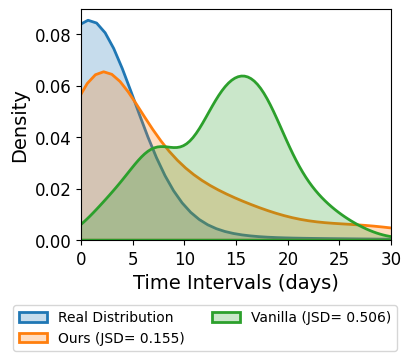

In [21]:
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt

def hour_diff(t1, t2):
    fmt = "%Y-%m-%d %H:%M:%S"
    dt1 = datetime.strptime(t1, fmt)
    dt2 = datetime.strptime(t2, fmt)
    diff = dt2 - dt1
    return diff.total_seconds() / (3600.0 * 24)

def js_divergence(counts_p, counts_q, eps=1e-12):
    p = np.asarray(counts_p, dtype=float)
    q = np.asarray(counts_q, dtype=float)

    # 归一化
    p_sum = p.sum()
    q_sum = q.sum()
    if p_sum == 0 or q_sum == 0:
        raise ValueError("One of the distributions has zero total count.")
    p /= p_sum
    q /= q_sum
    # print(p)
    # print(q)
    # 避免 log(0)
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log(p / m)) + np.sum(q * np.log(q / m))), p, q


def jsd_from_raw_samples(x, y, bin_edges):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # 统计两个分布的频数
    hist_x, _ = np.histogram(x, bins=bin_edges)
    hist_y, _ = np.histogram(y, bins=bin_edges)

    jsd, p, q = js_divergence(hist_x, hist_y)
    return jsd, hist_x, hist_y

# bin_edges = list(np.arange(0, 1.0, 0.05)) + list(np.arange(1, 48.0, 0.5)) + [np.inf]
bin_edges = list(np.arange(0, 1, 0.1)) + list(np.arange(1, 21, 2.0)) + [np.inf]

gold_hours_diff = []
for x in tqdm(gold_events):
    for i in range(1, len(x['events'])):
        diff = hour_diff(x['events'][i-1]['timestamp'], x['events'][i]['timestamp'])
        gold_hours_diff.append(diff)

right_max = 30

plt.figure(figsize=(4, 3))
sns.kdeplot(
    gold_hours_diff, 
    label='Real Distribution', 
    linewidth=2,
    bw_adjust=4.0,
    fill=True
)

name2label = {
    'livesim': 'Ours',
    'profile2traj': 'Vanilla'
}

for name in final_data:
    if 'mob' in name:
        continue
    pred_hours_diff = []
    for x in tqdm(final_data[name]):
        if 'results' in x:
            for i in range(1, len(x['results'])):
                diff = hour_diff(x['results'][i-1]['time'].split(',')[0], x['results'][i]['time'].split(',')[0])
                pred_hours_diff.append(diff)
        else:
            for i in range(1, len(x['events'])):
                diff = hour_diff(x['events'][i-1]['time'].split(',')[0], x['events'][i]['time'].split(',')[0])
                pred_hours_diff.append(diff)

    score, hist_x, hist_y = jsd_from_raw_samples(x=gold_hours_diff, y=pred_hours_diff, bin_edges=bin_edges)
    print(name, score)
    sns.kdeplot(
        pred_hours_diff, 
        label=name2label[name] + f" (JSD={score: .3f})", 
        linewidth=2,
        fill=True
    )

plt.xlim(0, right_max)
plt.xlabel("Time Intervals (days)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.02))
plt.legend(
    fontsize=10,
    loc='upper center',          # legend 的左侧对齐点
    bbox_to_anchor=(0.4, -0.25),  # (x, y) → x>1 将其移到图外右边
    ncol=2
)
plt.savefig(
    '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/pics/jsd_time_interval.pdf',
    format='pdf',
    bbox_inches='tight'
)
plt.show()

100%|██████████| 120/120 [00:00<00:00, 6610.50it/s]


livesim 0.22903364141790508


100%|██████████| 120/120 [00:00<00:00, 1318.05it/s]


profile2traj 0.4936522370628229


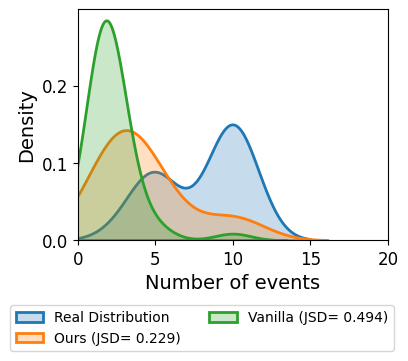

In [20]:
import numpy as np
from datetime import datetime
from tqdm import tqdm

def month_key(ts):
    """把时间戳转为 'YYYY-MM'"""
    dt = datetime.strptime(ts, "%Y-%m-%d %H:%M:%S")
    return dt.strftime("%Y-%m")

def count_events_per_month(event_list, timestamp_key="timestamp"):
    """
    输入：单个序列的 events 列表
    输出：该序列中每个月的事件数量（list），例如 [3, 5, 2, ...]
    """
    month_counts = {}
    for ev in event_list:
        ts = ev[timestamp_key]
        mk = month_key(ts)
        month_counts[mk] = month_counts.get(mk, 0) + 1
    
    # 返回按月份排序后的 list（保证一致性）
    return [month_counts[k] for k in sorted(month_counts.keys())]

def js_divergence(counts_p, counts_q, eps=1e-12):
    p = np.asarray(counts_p, dtype=float)
    q = np.asarray(counts_q, dtype=float)
    p /= p.sum()
    q /= q.sum()

    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    m = 0.5 * (p + q)

    return 0.5 * (np.sum(p * np.log(p / m)) + np.sum(q * np.log(q / m)))


def jsd_from_raw_samples(x, y, bin_edges):
    hist_x, _ = np.histogram(x, bins=bin_edges)
    hist_y, _ = np.histogram(y, bins=bin_edges)
    jsd = js_divergence(hist_x, hist_y)
    return jsd, hist_x, hist_y


# =======================
# 下面是你的新需求主逻辑
# =======================

# 1. 统计 GOLD 每月事件数
gold_month_counts = []
for seq in tqdm(gold_events):
    re = count_events_per_month(seq['events'], timestamp_key="timestamp")
    gold_month_counts.append(np.mean(re))

# print(gold_month_counts)
right_max = 20
plt.figure(figsize=(4, 3))
sns.kdeplot(
    gold_month_counts, 
    label='Real Distribution', 
    linewidth=2,
    bw_adjust=2.0,
    fill=True
)

name2label = {
    'livesim': 'Ours',
    'profile2traj': 'Vanilla'
}

# 2. 分箱规则（可调整）
#    例如：事件数可能大多在 0~50 之间：可以用每 2 个事件一个区间
bin_edges = list(np.arange(0, 100, 2)) + [np.inf]

# 3. 遍历预测数据集
for name in final_data:
    if 'mob' in name:
        continue
    pred_month_counts = []
    for seq in tqdm(final_data[name]):

        if "results" in seq:
            # 处理时间字段如 "2012-04-03 09:10:00, 星期六"
            events = [
                {"timestamp": e["time"].split(",")[0]}
                for e in seq["results"]
            ]
        else:
            events = [
                {"timestamp": e["time"].split(",")[0]}
                for e in seq["events"]
            ]
        re = count_events_per_month(events, timestamp_key="timestamp")
        pred_month_counts.append(np.mean(re))
    # print(pred_month_counts)
    # 4. 计算 JSD
    score, _, _ = jsd_from_raw_samples(
        x=gold_month_counts,
        y=pred_month_counts,
        bin_edges=bin_edges
    )
    print(name, score)
    
    sns.kdeplot(
        pred_month_counts, 
        label=name2label[name] + f" (JSD={score: .3f})", 
        linewidth=2,
        bw_adjust=2.0,
        fill=True
    )

plt.xlim(0, right_max)
plt.xlabel("Number of events", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.1))
plt.legend(
    fontsize=10,
    loc='upper center',          # legend 的左侧对齐点
    bbox_to_anchor=(0.4, -0.25),  # (x, y) → x>1 将其移到图外右边
    ncol=2
)
plt.savefig(
    '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/pics/jsd_monthly_events.pdf',
    format='pdf',
    bbox_inches='tight'
)
plt.show()

In [3]:
import numpy as np
from datetime import datetime
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


# ===============================
# 工具函数：初始化月份 dict
# ===============================
def init_month_counts(start="2012-01", end="2013-12"):
    """
    返回一个 dict，键为 'YYYY-MM'，值初始化为 0
    """
    start_dt = datetime.strptime(start, "%Y-%m")
    end_dt = datetime.strptime(end, "%Y-%m")
    cur = start_dt
    
    month_dict = {}
    while cur <= end_dt:
        key = cur.strftime("%Y-%m")
        month_dict[key] = 0
        if cur.month == 12:
            cur = datetime(cur.year + 1, 1, 1)
        else:
            cur = datetime(cur.year, cur.month + 1, 1)
    return month_dict


def month_key(ts):
    """
    把时间戳 'YYYY-MM-dd HH:MM:SS' -> 'YYYY-MM'
    """
    dt = datetime.strptime(ts, "%Y-%m-%d %H:%M:%S")
    return dt.strftime("%Y-%m")


# ===============================
# 从一堆 events 里统计 “事件发生月份” 频率分布
# events: list[{"timestamp": "..."}]
# 返回：
#   probs: np.array, shape = (24,) 概率分布
#   month_list: ['2012-01', ..., '2013-12'] 方便画图
# ===============================
def month_frequency_from_events(all_events, start="2012-01", end="2013-12"):
    month_counts = init_month_counts(start, end)

    # 累积每个事件所在月份
    for ev in all_events:
        ts = ev["timestamp"]
        mk = month_key(ts)
        if mk in month_counts:   # 防止超出范围
            month_counts[mk] += 1

    # 转成 list 并归一化为频率
    months_sorted = sorted(month_counts.keys())
    counts = np.array([month_counts[m] for m in months_sorted], dtype=float)
    total = counts.sum()
    if total == 0:
        # 没有事件的极端情况，返回均匀分布也行
        probs = np.ones_like(counts) / len(counts)
    else:
        probs = counts / total
    return probs, months_sorted


# ===============================
# JS Divergence
# ===============================
def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log(p / m)) + np.sum(q * np.log(q / m)))


# ===============================
# 1. GOLD：汇总所有事件 → 按月份统计频率
# ===============================
gold_all_events = []
for seq in tqdm(gold_events):
    for ev in seq["events"]:
        gold_all_events.append({"timestamp": ev["timestamp"]})

gold_probs, month_list = month_frequency_from_events(
    gold_all_events,
    start="2012-01",
    end="2013-4"
)

# 画 GOLD 的月度频率分布
x = np.arange(len(month_list))
plt.figure(figsize=(10, 5))
plt.plot(x, gold_probs, marker="o", label="Real Distribution")
plt.xticks(x, month_list, rotation=45)
plt.ylabel("Monthly Event Frequency")
plt.xlabel("Month")
plt.grid(alpha=0.3)

# ===============================
# 2. 遍历预测数据：同样统计“事件发生月份”的频率
# ===============================
for name in final_data:
    if "mob" in name:
        continue

    pred_all_events = []
    for seq in tqdm(final_data[name]):
        # 兼容两种结构
        if "results" in seq:
            for e in seq["results"]:
                ts = e["time"].split(",")[0]  # "YYYY-MM-dd HH:MM:SS"
                pred_all_events.append({"timestamp": ts})
        else:
            for e in seq["events"]:
                ts = e["time"].split(",")[0]
                pred_all_events.append({"timestamp": ts})

    pred_probs, _ = month_frequency_from_events(
        pred_all_events,
        start="2012-01",
        end="2013-4"
    )

    # 计算 JSD（对 24 维月份分布）
    jsd = js_divergence(gold_probs, pred_probs)

    # 画曲线
    plt.plot(
        x, pred_probs, marker="o",
        label=f"{name} (JSD={jsd:.3f})"
    )

plt.title("Event Month Frequency Distribution")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'gold_events' is not defined

In [ ]:
import numpy as np
from datetime import datetime
from tqdm import tqdm


def extract_hour(ts):
    """从时间戳提取小时，返回整数 0~23"""
    dt = datetime.strptime(ts, "%Y-%m-%d %H:%M:%S")
    return dt.hour


def collect_hour_values(event_list, timestamp_key="timestamp"):
    """
    输入：单个事件序列的 events 列表
    输出：该序列中所有事件发生的小时（0~23）组成的 list
    """
    hours = []
    for ev in event_list:
        ts = ev[timestamp_key]
        hour = extract_hour(ts)
        hours.append(hour)
    return hours


def js_divergence(counts_p, counts_q, eps=1e-12):
    """输入两个频数向量，计算 JSD（自然对数底）"""
    p = np.asarray(counts_p, dtype=float)
    q = np.asarray(counts_q, dtype=float)

    # 归一化
    p /= p.sum()
    q /= q.sum()

    # 防 log(0)
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log(p / m)) + np.sum(q * np.log(q / m)))


def jsd_from_raw_samples(x, y, bin_edges):
    """把原始样本 x,y 按 bin_edges 分箱，然后计算 JSD"""
    hist_x, _ = np.histogram(x, bins=bin_edges)
    hist_y, _ = np.histogram(y, bins=bin_edges)
    jsd = js_divergence(hist_x, hist_y)
    return jsd, hist_x, hist_y


# =======================
# 下面是你的主逻辑（仿造 month 版本）
# =======================

right_max = 24
# 1. 收集 GOLD 的所有事件小时值
gold_hour_values = []
for seq in tqdm(gold_events):
    hours = collect_hour_values(seq["events"], timestamp_key="timestamp")
    gold_hour_values.extend(hours)

sns.kdeplot(
    gold_hour_values, 
    label='Real Distribution', 
    linewidth=2,
    # bw_adjust=4.0,
    fill=True
)

# 2. 自定义分箱规则（可根据需求调整）
#    例如将 0~23 小时分为：
#    0–4, 5–8, 9–12, 13–16, 17–20, >=21
#    最后一个区间包含全部 21–23
bin_edges = list(np.arange(0, 25, 1))


# 3. 遍历预测数据集，统计小时分布并计算 JSD
for name in final_data:
    if 'mob' in name:
        continue

    pred_hour_values = []

    for seq in tqdm(final_data[name]):

        if "results" in seq:
            # 时间格式类似 "2012-04-03 18:00:09, 星期六"
            events = [
                {"timestamp": e["time"].split(",")[0]}
                for e in seq["results"]
            ]
        else:
            events = [
                {"timestamp": e["time"].split(",")[0]}
                for e in seq["events"]
            ]

        hours = collect_hour_values(events, timestamp_key="timestamp")
        pred_hour_values.extend(hours)

    # 4. 计算 JSD
    score, hist_gold, hist_pred = jsd_from_raw_samples(
        x=gold_hour_values,
        y=pred_hour_values,
        bin_edges=bin_edges
    )

    print(name, score)
    sns.kdeplot(
        pred_hour_values, 
        label=name + f" ({score: .3f})", 
        linewidth=2,
        bw_adjust=2.0,
        fill=True
    )

plt.xlim(0, right_max)
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()